# 02｜隐藏状态与循环记忆

RNN 的关键不是“输入很多数字”，而是每个时间步都把上一步的隐藏状态 `h_(t-1)` 带到下一步。

\[
h_t=	anh(W_xx_t+W_hh_{t-1}+b)
\]

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "rnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "03_rnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：每个 Notebook 只占用一个 CPU 计算线程。
torch.set_num_threads(1)

from rnn_lab import (
    ExperimentConfig, run_experiment, plot_hidden_states,
    plot_input_gradients, plot_recurrence_diagram, plot_sequence_sample,
)

## 把一个循环单元沿时间展开

图中的每个蓝色方块使用同一组参数。看起来是很多个单元，实际是同一个单元在不同时间重复工作。

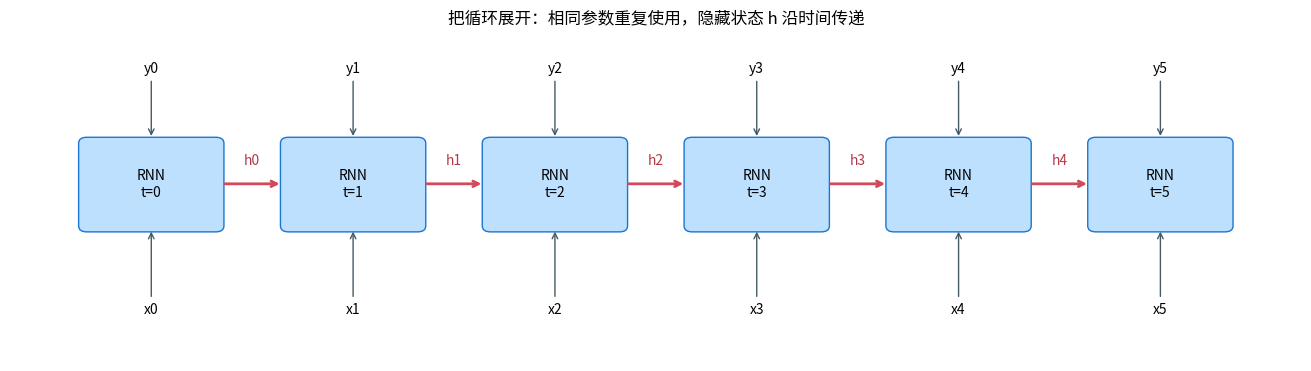

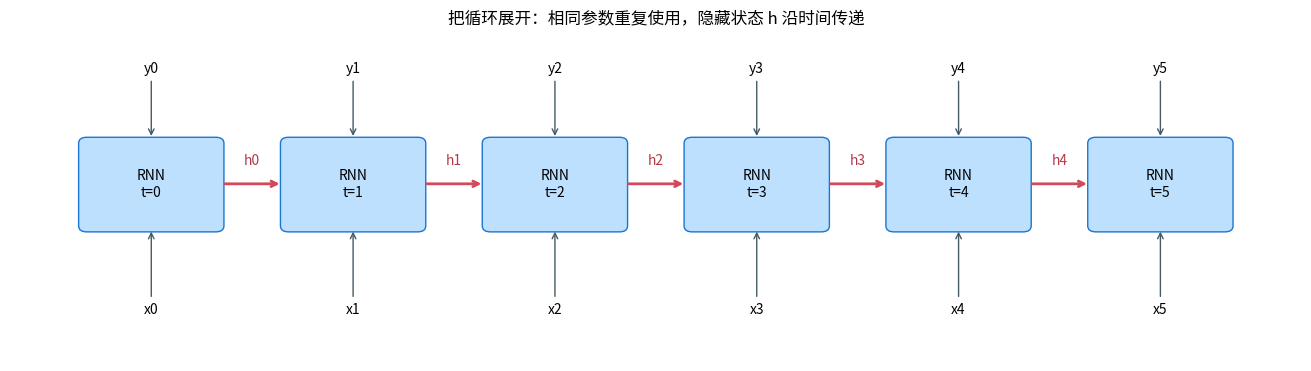

In [2]:
plot_recurrence_diagram(steps=6)

## 训练一个短序列 RNN，再观察内部表示

隐藏状态热力图只能描述数值怎样变化，不能当作“模型思维”的完整证明。输入梯度图回答的是：当前输出对各时间步输入有多敏感。

输入 shape [B,T,F]： (4, 12, 6)
隐藏输出 shape [B,T,H]： (4, 12, 16)
分类 logits shape [B,classes]： (4, 3)


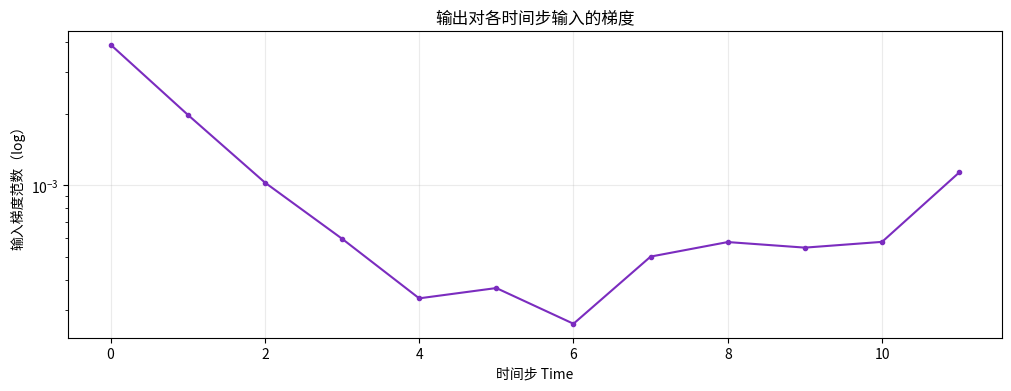

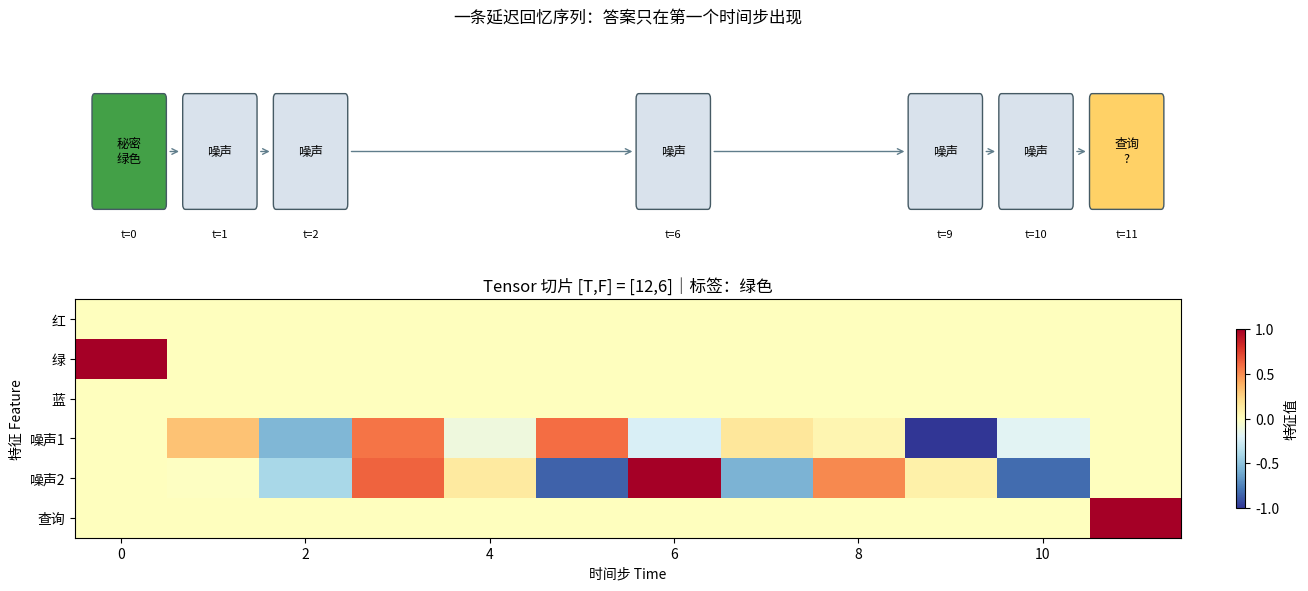

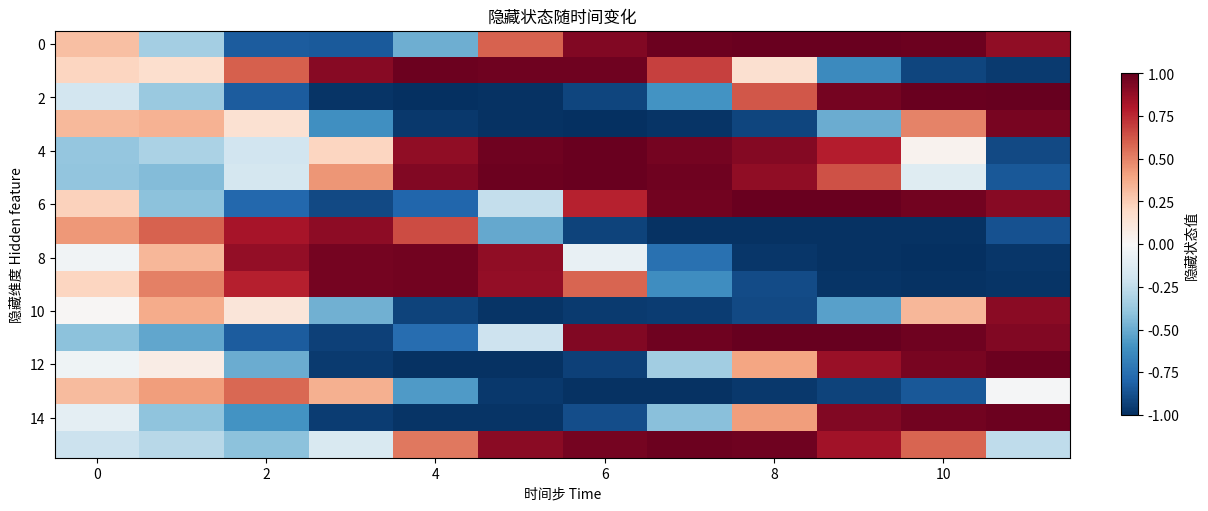

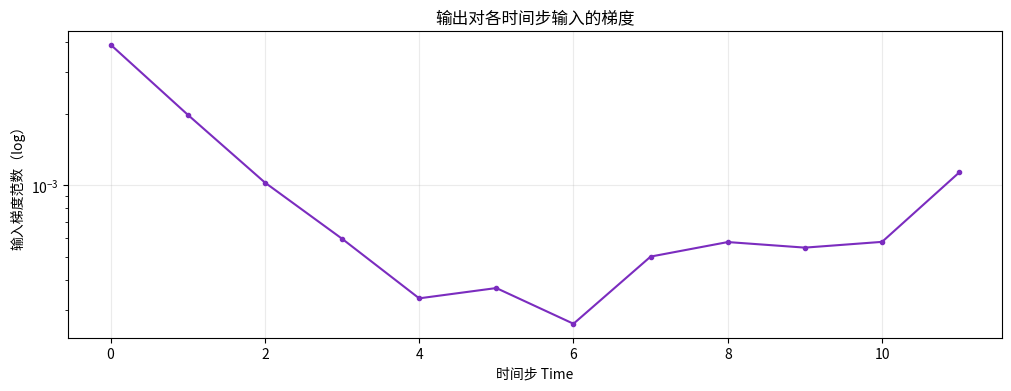

In [3]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 "cuda:x"；本实验很小，默认 CPU 更合适。
config = ExperimentConfig(
    cell_type="rnn", sequence_length=12, hidden_size=16, epochs=25,
    train_size=600, val_size=180, test_size=180, batch_size=64,
    seed=42, device=DEVICE,
)
result = run_experiment(config)
test_x, test_y = next(iter(result["loaders"]["test"]))

hidden = result["model"].sequence_features(test_x[:4])
print("输入 shape [B,T,F]：", tuple(test_x[:4].shape))
print("隐藏输出 shape [B,T,H]：", tuple(hidden.shape))
print("分类 logits shape [B,classes]：", tuple(result["model"](test_x[:4]).shape))

plot_sequence_sample(test_x, test_y)
plot_hidden_states(result["model"], test_x, device=DEVICE)
plot_input_gradients(result["model"], test_x, test_y, device=DEVICE)

## 读图时注意

- 隐藏向量不是一个“答案格子”，而是一组共同编码信息的数值；
- 远处输入梯度很小可能提示梯度消失，但单个样本不能证明一般规律；
- 梯度裁剪主要限制过大梯度，不能自动解决长期记忆问题。

## 完成本页后：释放资源并结束内核

运行下面最后一个单元格会清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后 VS Code 显示“内核已停止”或要求重新选择内核属于正常现象。再次实验时重新选择课程内核即可。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)